In [80]:
from process_bin_root import *
from modelling_data import ajuste_lineal
from sklearn.cluster import DBSCAN
import ROOT

## Carga de datos

Defino las carpetas y paths a analizar

In [81]:
folders = ["20251125-protonterapia", "20251126-pterapia", "20251127-pterapia"]
path = lambda folder: f"/home/lexi/Documentos/Datos CNEA/CAC_Protonterapia/2025_11_protonterapia/{folder}/DAQ/"

Chequeo sanidad de los datos en la carpeta y me quedo con aquellos que tienen dos canales (BIN_sanity es lo que tarda más, ejecutar una vez)

In [82]:
folder = folders[2]
BIN_check = BIN_sanity(path(folder))

In [83]:
for tipo in BIN_check:
    print('Hay', len(BIN_check[tipo]), 'archivos', tipo)

Hay 6 archivos empty
Hay 3 archivos broken
Hay 52 archivos 1_ch
Hay 28 archivos 2_ch


In [84]:
BINs_2ch = BIN_check['2_ch']
BINs_2ch

['20251127_run_alpha_11',
 '20251127_run_alpha_3',
 '20251127_run_alpha_4',
 '20251127_run_alpha_5',
 '20251127_run_alpha_6',
 '20251127_run_protons_18MeV_1',
 '20251127_run_protons_18MeV_1lexan_1',
 '20251127_run_protons_19MeV_1',
 '20251127_run_protons_19MeV_rf9_1',
 '20251127_run_protons_19MeV_rf_1',
 '20251127_run_protons_20MeV_1',
 '20251127_run_protons_20MeV_2',
 '20251127_run_protons_20MeV_3',
 '20251127_run_protons_20MeV_rf9_1',
 '20251127_run_protons_20MeV_rf_1',
 '20251127_run_protons_rf9_18MeV_1',
 '20251127_run_protons_rf9_18MeV_2',
 '20251127_run_protons_rf9_18MeV_3',
 '20251127_run_protons_rf9_18MeV_4',
 '20251127_run_protons_rf9_18MeV_5',
 '20251127_run_protons_rf9_18MeV_6',
 '20251127_run_protons_rf9_1lexan_18MeV_1',
 '20251127_run_protons_rf_18MeV_1',
 '20251127_run_protons_rf_18MeV_2',
 '20251127_run_protons_rf_1lexan_18MeV_1',
 '20251127_run_protons_rf_tapa_18MeV_1',
 '20251127_run_protons_rf_tapa_18MeV_2',
 '20251127_run_protons_tapa_18MeV_1']

In [85]:
run = '20251127_run_protons_rf_18MeV_2'
pathBIN = glob.glob(path(folder) + run + '/RAW/*.BIN')[0]
print('Analizando...\n', pathBIN)

Analizando...
 /home/lexi/Documentos/Datos CNEA/CAC_Protonterapia/2025_11_protonterapia/20251127-pterapia/DAQ/20251127_run_protons_rf_18MeV_2/RAW/SDataR_20251127_run_protons_rf_18MeV_2.BIN


In [86]:
dfBIN = bin_to_df(pathBIN)

In [87]:
pathROOT = glob.glob(path(folder) + run + '/RAW/*.root')[0]
rootfile = ROOT.TFile.Open(pathROOT)

In [88]:
dfROOT = (
    hist_root(rootfile)
    .rename(columns = {
        'bins_center': 'Energy',
        'counts': 'Counts'
        })
)

## Calibración

In [89]:
df_coef = pd.read_csv('coef_calib_energia.csv')
df_coef

,det,m,b,R2
0,0,0.008826,2.339336,0.999544
1,1,0.022521,2.436750,0.999876


In [90]:
df_coef_LISE = pd.read_csv('coef_calib_energia_LISE.csv')
df_coef_LISE

,det,m,b,R2
0,0,0.010157,0.949446,0.999791
1,1,0.025912,1.062250,0.999675


In [91]:
dfROOT = apply_calibration_en(dfROOT, df_coef, move_old_to = 'Energy_Ch')
dfBIN = apply_calibration_en(dfBIN, df_coef, move_old_to = 'Energy_Ch')

In [92]:
dfROOT = apply_calibration_en(dfROOT, df_coef_LISE, col = 'Energy_Ch', new = 'Energy_LISE')
dfBIN = apply_calibration_en(dfBIN, df_coef_LISE, col = 'Energy_Ch', new = 'Energy_LISE')

## Histogramas por canal

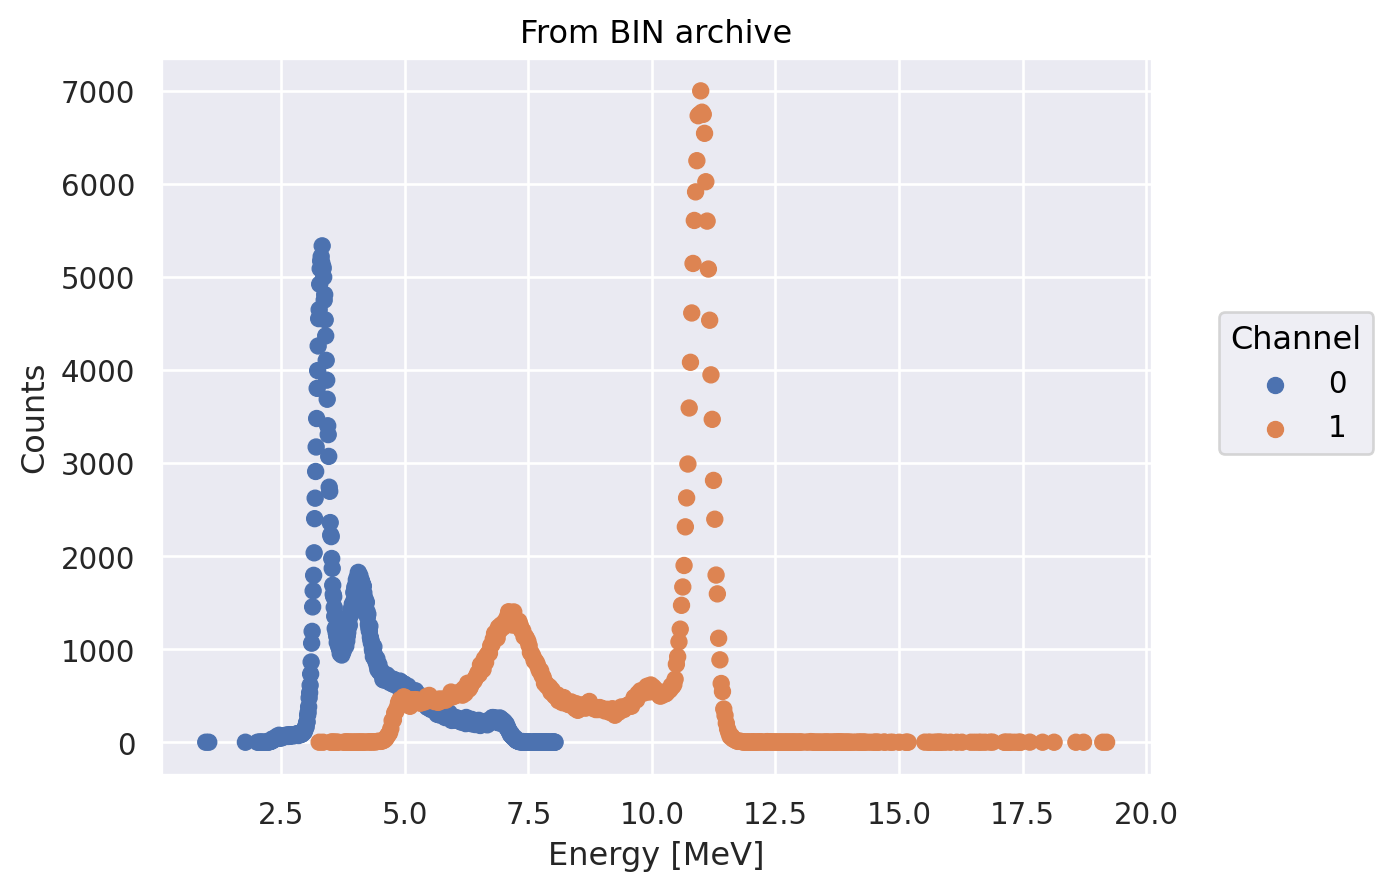

In [93]:
dfBIN_hist = hist_bin(dfBIN)
dfBIN_hist_filt = filter_hist(dfBIN_hist, counts_min= 1, ch_min=1, ch_max= 700)
dfBIN_hist_filt = apply_calibration_en(dfBIN_hist_filt, df_coef_LISE, col = 'Energy_Ch', new = 'Energy_LISE')

(
    so.Plot(data = dfBIN_hist_filt, x = 'Energy_LISE', y = 'Counts', color = dfBIN_hist_filt.Channel.astype(str))
    .add(so.Dot())
    .label(x = 'Energy [MeV]', y = 'Counts', title = 'From BIN archive')
)

In [94]:
dfROOT_filt = filter_hist(dfROOT, counts_min= 1, ch_min=1, ch_max= 700, x_col= 'Energy_Ch')
dfROOT_hist_filt = apply_calibration_en(dfROOT_filt, df_coef, col = 'Energy_Ch', new = 'Energy')


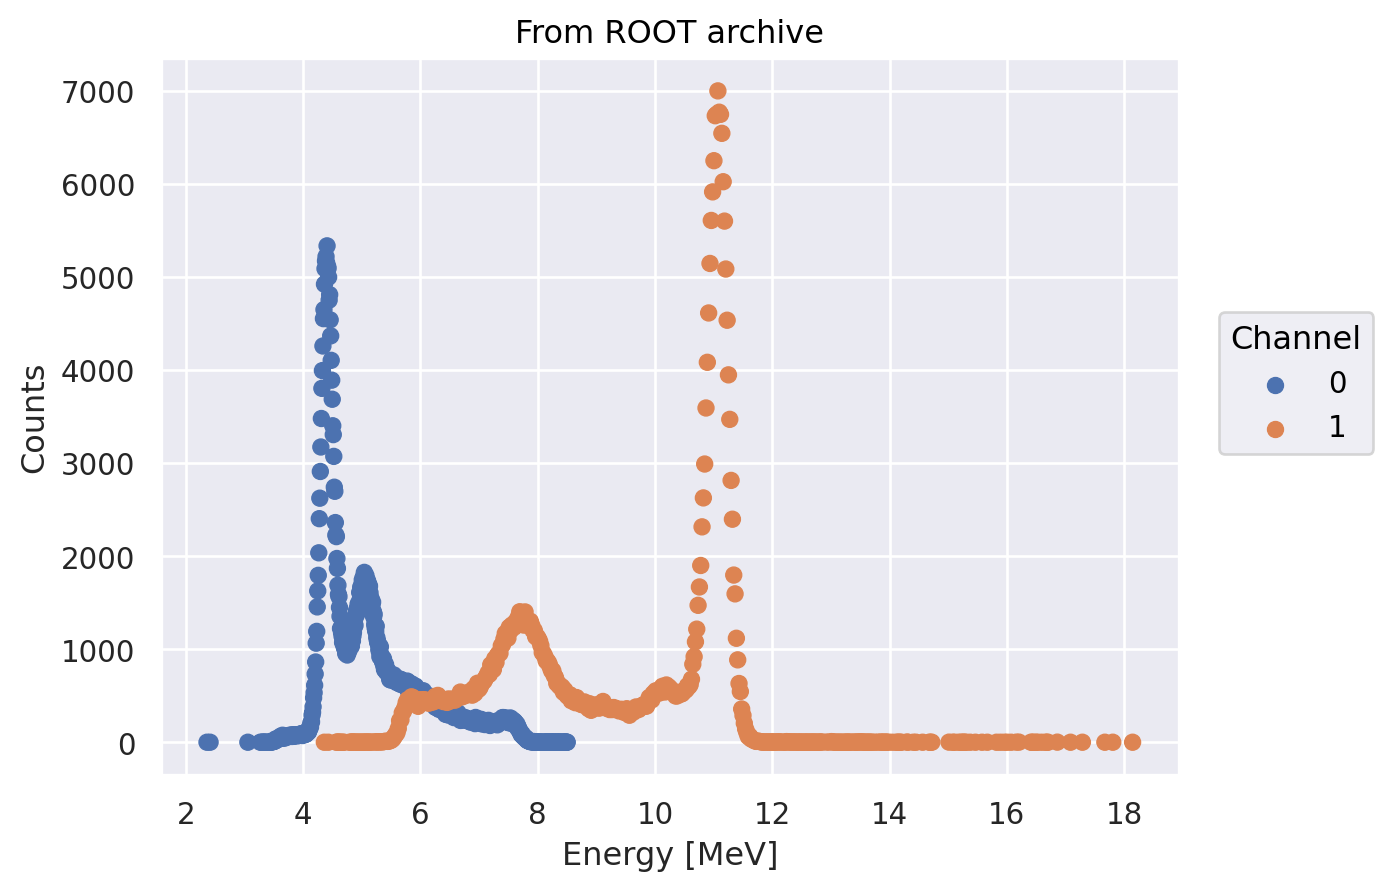

In [95]:
(
    so.Plot(data = dfROOT_filt, x = 'Energy', y = 'Counts', color = dfROOT_filt.Channel.astype(str))
    .add(so.Dot())
    .label(x = 'Energy [MeV]', y = 'Counts', title = 'From ROOT archive')
)

## Coincidencias

In [96]:
df_coinc = df_coincidences(dfBIN, det_E = 0, det_dE = 1, window_ns = 600, Energy_col= ['Energy_Ch', 'Energy', 'Energy_LISE'])

In [97]:
df_coinc_wo_0 = df_coinc[(df_coinc.Energy_Ch_E > 0) & (df_coinc.Energy_Ch_dE > 0)]
df_coinc_wo_0.head()

,i,j,Energy_Ch_E,Energy_Ch_dE,Energy_E,Energy_dE,Energy_LISE_E,Energy_LISE_dE
0,0,0,243,371,4.484007,10.791968,3.417608,10.675575
1,2,1,258,315,4.616394,9.530803,3.569963,9.224507
2,3,2,229,382,4.360445,11.039697,3.275409,10.960606
3,6,3,243,392,4.484007,11.264905,3.417608,11.219726
4,7,4,232,392,4.386923,11.264905,3.305880,11.219726


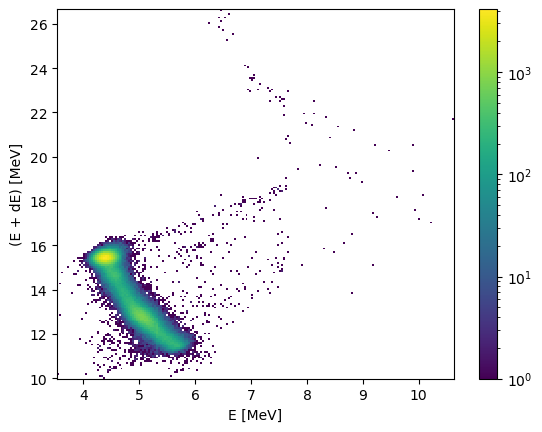

In [98]:
coinc_data = graph_coincidences(df_coinc_wo_0, Energy_col= 'Energy', add_both=True)

In [99]:
find_max = lambda data: np.unravel_index(np.argmax(data, axis=None), data.shape)

imax, jmax = find_max(coinc_data[0])
print('Maximo en', 'E:', coinc_data[1][imax], 'MeV | E+dE:', coinc_data[2][jmax], 'MeV')

Maximo en E: 4.346853605369679 MeV | E+dE: 15.404143572120821 MeV


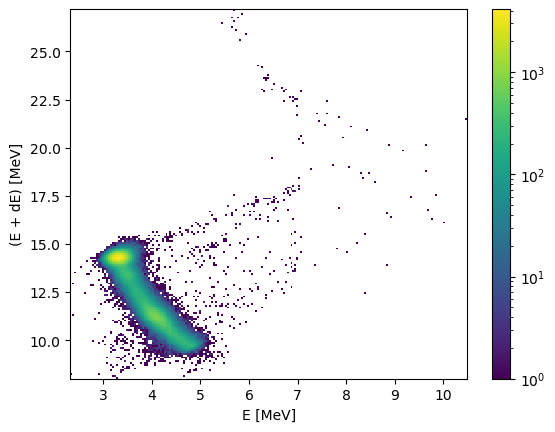

In [100]:
coind_data_LISE = graph_coincidences(df_coinc_wo_0, Energy_col= 'Energy_LISE', add_both=True)

In [101]:
imax, jmax = find_max(coind_data_LISE[0])
print('Maximo en', 'E:', coind_data_LISE[1][imax], 'MeV | E+dE:', coind_data_LISE[2][jmax], 'MeV')

Maximo en E: 3.2597670615810554 MeV | E+dE: 14.24079598230811 MeV
